# Problem 3(1): Q-Learning and Algorithmic Collusion — Baseline ($\xi = 0$)

This notebook implements the Q-learning simulation for informed speculators following the protocol of Dou et al. (2025). We investigate whether model-free Q-learning algorithms, acting as informed speculators, can learn to **collude without explicit communication**.

**Outline:**
1. Model parameters and equilibrium computation
2. Discretisation of state and action spaces
3. Q-matrix initialisation
4. Q-learning algorithm
5. Part (a): Sanity check with $I=1$
6. Part (b): Two-speculator simulation with $I=2$
7. Convergence analysis and collusion index


## 1. Model Parameters and Equilibrium Computation

We first set the global parameters specified in the project, and compute the Nash and Cartel equilibrium values using the closed-form expressions from Problem 1(4).

**Parameters:**
- $\bar{v} = 1$, $\sigma_v = 1$, $\sigma_u = 0.1$, $\theta = 0.1$
- $\rho = 0.95$ (discount factor), $\alpha = 0.05$ (learning rate), $\beta = 5 \times 10^{-6}$ (exploration decay)
- $\iota = 0.1$ (grid buffer), $n_v = 10$, $n_x = 15$, $n_p = 31$

**Closed-form equilibria ($\xi = 0$):**
$$\chi^N = \frac{\sigma_u}{\sqrt{I}\,\sigma_v}, \quad \lambda^N = \frac{\sqrt{I}}{I+1}\frac{\sigma_v}{\sigma_u}, \quad \chi^M = \frac{\sigma_u}{I\,\sigma_v}, \quad \lambda^M = \frac{\sigma_v}{2\sigma_u}$$


In [2]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import time

# ---- Global parameters (from project specification) ----
v_bar   = 1.0
sigma_v = 1.0
sigma_u = 0.1
theta   = 0.1
rho     = 0.95    # discount factor
alpha   = 0.05    # learning rate
beta    = 5e-6    # exploration decay speed
iota    = 0.1     # grid buffer
n_v     = 10      # number of v grid points
n_x     = 15      # number of action grid points
n_p     = 31      # number of price grid points


In [3]:

def compute_equilibrium_xi0(I, sigma_v, sigma_u):
    """
    Closed-form Nash and Cartel equilibrium for xi = 0.

    Nash:   chi_N = sigma_u / (sqrt(I) * sigma_v)
            lambda_N = sqrt(I)/(I+1) * sigma_v/sigma_u
    Cartel: chi_M = sigma_u / (I * sigma_v)
            lambda_M = sigma_v / (2 * sigma_u)
    """
    chi_N    = sigma_u / (np.sqrt(I) * sigma_v)
    lambda_N = np.sqrt(I) / (I + 1) * (sigma_v / sigma_u)
    pi_N     = (1 - lambda_N * I * chi_N) * chi_N * sigma_v**2

    chi_M    = sigma_u / (I * sigma_v)
    lambda_M = sigma_v / (2 * sigma_u)
    pi_M     = (1 - lambda_M * I * chi_M) * chi_M * sigma_v**2

    return chi_N, chi_M, lambda_N, lambda_M, pi_N, pi_M

# Compute for I=1 and I=2
for I_val in [1, 2]:
    chi_N, chi_M, lam_N, lam_M, pi_N, pi_M = compute_equilibrium_xi0(I_val, sigma_v, sigma_u)
    print(f"I = {I_val}:")
    print(f"  chi_N = {chi_N:.6f},  chi_M = {chi_M:.6f}")
    print(f"  lambda_N = {lam_N:.6f},  lambda_M = {lam_M:.6f}")
    print(f"  pi_N = {pi_N:.6f},  pi_M = {pi_M:.6f}")
    print()



I = 1:
  chi_N = 0.100000,  chi_M = 0.100000
  lambda_N = 5.000000,  lambda_M = 5.000000
  pi_N = 0.050000,  pi_M = 0.050000

I = 2:
  chi_N = 0.070711,  chi_M = 0.050000
  lambda_N = 4.714045,  lambda_M = 5.000000
  pi_N = 0.023570,  pi_M = 0.025000



## 2. Discretisation of State and Action Spaces

Q-learning requires finite state and action spaces. We discretise three continuous variables:

### 2.1 Fundamental value grid $\{v_1, \ldots, v_{n_v}\}$

The distribution $\mathcal{N}(\bar{v}, \sigma_v^2)$ is approximated by $n_v = 10$ equal-probability grid points:
$$v_k = \bar{v} + \sigma_v \Phi^{-1}\left(\frac{2k-1}{2n_v}\right), \quad k = 1, \ldots, n_v$$

Each $v_k$ is the midpoint of its probability bin, ensuring uniform visitation when sampling from the grid.


In [4]:
def build_v_grid(v_bar, sigma_v, n_v):
    """
    Discretise N(v_bar, sigma_v^2) into n_v equal-probability grid points.
    v_k = v_bar + sigma_v * Phi^{-1}((2k-1)/(2*n_v))
    """
    v_grid = np.array([
        v_bar + sigma_v * norm.ppf((2*k - 1) / (2*n_v))
        for k in range(1, n_v + 1)
    ])
    return v_grid

v_grid = build_v_grid(v_bar, sigma_v, n_v)
print("v_grid:")
for k, v in enumerate(v_grid):
    print(f"  v_{k+1:>2d} = {v:.4f}  (v_k - v_bar = {v - v_bar:+.4f})")


v_grid:
  v_ 1 = -0.6449  (v_k - v_bar = -1.6449)
  v_ 2 = -0.0364  (v_k - v_bar = -1.0364)
  v_ 3 = 0.3255  (v_k - v_bar = -0.6745)
  v_ 4 = 0.6147  (v_k - v_bar = -0.3853)
  v_ 5 = 0.8743  (v_k - v_bar = -0.1257)
  v_ 6 = 1.1257  (v_k - v_bar = +0.1257)
  v_ 7 = 1.3853  (v_k - v_bar = +0.3853)
  v_ 8 = 1.6745  (v_k - v_bar = +0.6745)
  v_ 9 = 2.0364  (v_k - v_bar = +1.0364)
  v_10 = 2.6449  (v_k - v_bar = +1.6449)


In [5]:
def build_v_grild(v_bar, sigma_v, n_v):
  v_grid = np.array([v_bar + sigma_v * norm.ppf((2*k - 1) / (2*n_v)) for k in range(1, n_v+1)])
  return v_grid
v_grid = build_v_grid(v_bar, sigma_v, n_v)
print(v_grid)


[-0.64485363 -0.03643339  0.32551025  0.61467953  0.87433865  1.12566135
  1.38532047  1.67448975  2.03643339  2.64485363]


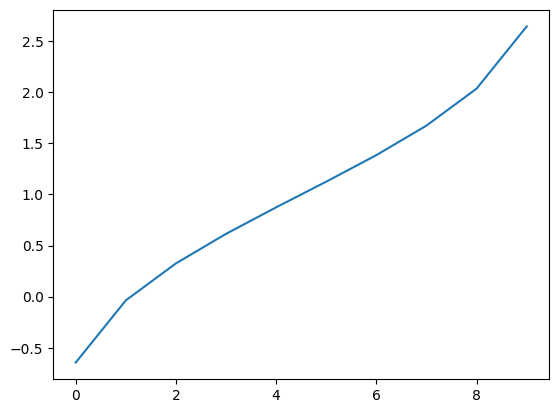

In [6]:
plt.plot(v_grid)

### 2.2 Action grid $\mathcal{X}_k$ (state-dependent)

For each $v_k$, the action grid spans the range between the Cartel and Nash order sizes, with a 10% buffer on each side:

- When $v_k > \bar{v}$: interval $= [x_k^M - \iota(x_k^N - x_k^M),\; x_k^N + \iota(x_k^N - x_k^M)]$
- When $v_k < \bar{v}$: reflected symmetrically

The grid contains $n_x = 15$ equally spaced points. This range ensures the algorithm can explore strategies from "more conservative than Cartel" to "more aggressive than Nash".


In [7]:
def build_action_grids(v_grid, v_bar, chi_N, chi_M, n_x, iota):
    """
    Build state-dependent action grids for each v_k.
    Range covers [Cartel - buffer, Nash + buffer] for v_k > v_bar,
    reflected for v_k < v_bar.
    """
    action_grids = []
    for v_k in v_grid:
        x_N_k = chi_N * (v_k - v_bar)
        x_M_k = chi_M * (v_k - v_bar)

        if v_k > v_bar:
            spread = x_N_k - x_M_k
            lo = x_M_k - iota * spread
            hi = x_N_k + iota * spread
        elif v_k < v_bar:
            spread = x_M_k - x_N_k
            lo = x_N_k - iota * spread
            hi = x_M_k + iota * spread
        else:
            lo, hi = 0.0, 0.0

        action_grids.append(np.linspace(lo, hi, n_x))
    return action_grids

# Example: build action grids for I=2
chi_N_2, chi_M_2, lam_N_2, _, _, _ = compute_equilibrium_xi0(1, sigma_v, sigma_u)
action_grids_2 = build_action_grids(v_grid, v_bar, chi_N_2, chi_M_2, n_x, iota)

# Show grid for a positive v_k
k = 8  # v_k > v_bar
print(f"Action grid for v_{k+1} = {v_grid[k]:.4f} (v_k - v_bar = {v_grid[k]-v_bar:+.4f}):")
print(f"  x_N_k = {chi_N_2*(v_grid[k]-v_bar):.6f}")
print(f"  x_M_k = {chi_M_2*(v_grid[k]-v_bar):.6f}")
print(f"  Grid ({len(action_grids_2[k])} points): [{action_grids_2[k][0]:.6f}, ..., {action_grids_2[k][-1]:.6f}]")


Action grid for v_9 = 2.0364 (v_k - v_bar = +1.0364):
  x_N_k = 0.103643
  x_M_k = 0.103643
  Grid (15 points): [0.103643, ..., 0.103643]


### 2.3 Price grid $\mathcal{P}_k$ (state-dependent)

For each $v_k$, the price grid covers the range of prices that could arise given all possible combinations of informed trading and noise trading:

$$p_{H,k} = \bar{v} + \lambda^N(I \max\{x_k^M, x_k^N\} + 1.96\sigma_u)$$
$$p_{L,k} = \bar{v} + \lambda^N(I \min\{x_k^M, x_k^N\} - 1.96\sigma_u)$$

The $1.96\sigma_u$ covers 95% of the noise trader distribution. The grid has $n_p = 31$ points with a 10% buffer on each side.


In [8]:
def build_price_grids(v_grid, v_bar, chi_N, chi_M, lambda_N, I, sigma_u, n_p, iota):
    """
    Build state-dependent price grids for each v_k.
    Covers range [p_L - buffer, p_H + buffer] with n_p points.
    """
    price_grids = []
    for v_k in v_grid:
        x_N_k = chi_N * (v_k - v_bar)
        x_M_k = chi_M * (v_k - v_bar)

        p_H = v_bar + lambda_N * (I * max(x_M_k, x_N_k) + 1.96 * sigma_u)
        p_L = v_bar + lambda_N * (I * min(x_M_k, x_N_k) - 1.96 * sigma_u)

        spread = p_H - p_L
        if spread < 1e-15:
            price_grids.append(np.linspace(v_bar - 0.1, v_bar + 0.1, n_p))
        else:
            lo = p_L - iota * spread
            hi = p_H + iota * spread
            price_grids.append(np.linspace(lo, hi, n_p))
    return price_grids

def snap_to_grid(value, grid):
    """Map a continuous value to the nearest grid point index."""
    return np.argmin(np.abs(grid - value))

price_grids_2 = build_price_grids(v_grid, v_bar, chi_N_2, chi_M_2, lam_N_2, 2, sigma_u, n_p, iota)

# Show grid for the same v_k
print(f"Price grid for v_{k+1} = {v_grid[k]:.4f}:")
print(f"  Range: [{price_grids_2[k][0]:.4f}, ..., {price_grids_2[k][-1]:.4f}]")
print(f"  Number of points: {len(price_grids_2[k])}")


Price grid for v_9 = 2.0364:
  Range: [0.8604, ..., 3.2124]
  Number of points: 31


In [9]:
'''def build_price_grids(v_grid, v_bar, chi_N, chi_M, lambda_N, I, sigma_u, n_p, iota):
  price_grids = []
  for v_k in v_grid:
    x_N_k = chi_N * (v_k - v_bar)
    x_M_k = chi_M * (v_k - v_bar)

    p_h_k = v_bar + lambda_N * (I * max(x_N_k , x_M_k) + 1.96* sigma_u)
    p_h_k = v_bar + lambda_N * (I * min(x_N_k , x_M_k) - 1.96* sigma_u)

    spread = p_h_k - p_l_k
    if spread < 1e-15:
      price_grids.append(np.linspace(v_bar - 0.1, v_bar + 0.1, n_p))

    else:
      lo = p_l_k - iota * spread
      hi = p_h_k + iota * spread
      price_grids.append(np.linspace(lo,hi, n_p))
  return price_grids

def snap_to_grid(p_val, p_grid):
  return np.argmin(np.abs(p_val - p_grid))
'''



'def build_price_grids(v_grid, v_bar, chi_N, chi_M, lambda_N, I, sigma_u, n_p, iota):\n  price_grids = []\n  for v_k in v_grid:\n    x_N_k = chi_N * (v_k - v_bar)\n    x_M_k = chi_M * (v_k - v_bar)\n\n    p_h_k = v_bar + lambda_N * (I * max(x_N_k , x_M_k) + 1.96* sigma_u)\n    p_h_k = v_bar + lambda_N * (I * min(x_N_k , x_M_k) - 1.96* sigma_u)\n\n    spread = p_h_k - p_l_k\n    if spread < 1e-15:\n      price_grids.append(np.linspace(v_bar - 0.1, v_bar + 0.1, n_p))\n\n    else:\n      lo = p_l_k - iota * spread\n      hi = p_h_k + iota * spread\n      price_grids.append(np.linspace(lo,hi, n_p))\n  return price_grids\n\ndef snap_to_grid(p_val, p_grid):\n  return np.argmin(np.abs(p_val - p_grid))\n'

## 3. Q-Matrix Initialisation

The Q-matrix is initialised according to equation (7) from the project:

$$\hat{Q}_{i,0}(s, x_n) = \frac{1}{(1-\rho) \, n_x} \sum_{x_{-i} \in \mathcal{X}_k} \left[v_k - \left(\bar{v} + \lambda^N(x_n + (I-1)x_{-i})\right)\right] x_n$$

**Interpretation:** This is the discounted payoff that speculator $i$ would earn if:
- The other $I-1$ speculators randomise their actions uniformly over the grid
- The noise trader's order is zero ($u_t = 0$)
- The game repeats forever (hence the $1/(1-\rho)$ discounting)

The value depends only on $(v_k, x_n)$ and is **replicated across all** $(p_{t-1}, v_{t-1})$ slices.

**Q-matrix shape:** `(n_p, n_v, n_v, n_x)` = $(31 \times 10 \times 10 \times 15) = 46{,}500$ entries, indexed by $(p_{t-1}, v_{t-1}, v_t, x)$.


In [10]:
def init_Q_matrix(v_grid, action_grids, price_grids, v_bar, lambda_N, I, rho, n_v, n_p):
    """
    Initialise Q-matrix per equation (7).

    For each (v_k, x_n) pair, compute the average profit assuming:
      - opponents randomise uniformly over X_k
      - noise trader order = 0
    Then discount by 1/(1-rho) and replicate across all (p_{t-1}, v_{t-1}) slices.
    """
    n_x = max(len(ag) for ag in action_grids)
    Q = np.zeros((n_p, n_v, n_v, n_x))

    for k in range(n_v):
        v_k = v_grid[k]
        X_k = action_grids[k]
        n_x_k = len(X_k)

        for n in range(n_x_k):
            x_n = X_k[n]
            # Average over all possible opponent actions
            payoff_sum = 0.0
            for x_minus_i in X_k:
                price = v_bar + lambda_N * (x_n + (I - 1) * x_minus_i)
                payoff = (v_k - price) * x_n
                payoff_sum += payoff
            avg_payoff = payoff_sum / n_x_k
            q_val = avg_payoff / (1 - rho)

            # Replicate across all (p_{t-1}, v_{t-1}) slices
            Q[:, :, k, n] = q_val

    return Q

# Demonstrate for I=2
Q_demo = init_Q_matrix(v_grid, action_grids_2, price_grids_2, v_bar, lam_N_2, 2, rho, n_v, n_p)
print(f"Q-matrix shape: {Q_demo.shape}")
print(f"Total entries: {Q_demo.size:,}")
print(f"\nSample Q-values for v_9 = {v_grid[8]:.4f}:")
for j in range(0, n_x, 3):
    print(f"  action[{j}] = {action_grids_2[8][j]:.6f}  ->  Q = {Q_demo[15, 5, 8, j]:.4f}")


Q-matrix shape: (31, 10, 10, 15)
Total entries: 46,500

Sample Q-values for v_9 = 2.0364:
  action[0] = 0.103643  ->  Q = 0.0000
  action[3] = 0.103643  ->  Q = 0.0000
  action[6] = 0.103643  ->  Q = 0.0000
  action[9] = 0.103643  ->  Q = 0.0000
  action[12] = 0.103643  ->  Q = 0.0000


In [11]:
def init_Q_matrix(v_grid, action_grids, price_grids, v_bar, lambda_N, I, rho, n_v, n_p):
  n_x = n_x = max(len(ag) for ag in action_grids)
  Q = np.zeros((n_p,n_v,n_v, n_x))

  for v_id,vk in enumerate(v_grid):
    X_k_grid = action_grids[v_id]
    n_x_k = len(X_k_grid)

    for n in range(n_x_k):
      x_n = X_k_grid[n]

      q_val = 1/(n_x_k * (1-rho)) * sum(
    (vk - (v_bar + lambda_N * (x_n + (I-1) * x_i_))) * x_n
    for x_i_ in X_k_grid
    )
      Q[:,:,v_id ,n] = q_val


  return Q

# Demonstrate for I=2
Q_demo = init_Q_matrix(v_grid, action_grids_2, price_grids_2, v_bar, lam_N_2, 2, rho, n_v, n_p)
print(f"Q-matrix shape: {Q_demo.shape}")
print(f"Total entries: {Q_demo.size:,}")
print(f"\nSample Q-values for v_9 = {v_grid[8]:.4f}:")
for j in range(0, n_x, 3):
    print(f"  action[{j}] = {action_grids_2[8][j]:.6f}  ->  Q = {Q_demo[15, 5, 8, j]:.4f}")


Q-matrix shape: (31, 10, 10, 15)
Total entries: 46,500

Sample Q-values for v_9 = 2.0364:
  action[0] = 0.103643  ->  Q = 0.0000
  action[3] = 0.103643  ->  Q = 0.0000
  action[6] = 0.103643  ->  Q = 0.0000
  action[9] = 0.103643  ->  Q = 0.0000
  action[12] = 0.103643  ->  Q = 0.0000


## 4. Q-Learning Algorithm

The core algorithm repeats for $T$ periods. At each period $t$:

| Step | Description |
|------|-------------|
| 1. **Observe state** | $s_t = (p_{t-1}, v_{t-1}, v_t)$ — previous price, previous fundamental, current fundamental |
| 2. **Choose action** | $\varepsilon$-greedy: exploit (pick best Q-value) with probability $1-\varepsilon_t$, explore (random) with probability $\varepsilon_t$ |
| 3. **Market clears** | Noise $u_t \sim \mathcal{N}(0, \sigma_u^2)$, total flow $y_t = I \cdot x_i + u_t$, price $p_t = \bar{v} + \lambda^N y_t$, profit $\pi_i = (v_t - p_t)x_i$ |
| 4. **Transition** | Draw $v_{t+1}$, new state $s_{t+1} = (p_t, v_t, v_{t+1})$ |
| 5. **Update Q** | $\hat{Q}(s_t, x_i) \leftarrow (1-\alpha)\hat{Q}(s_t, x_i) + \alpha[\pi_i + \rho \max_{x'} \hat{Q}(s_{t+1}, x')]$ |

**Key design choices:**
- All $I$ speculators are **symmetric**: they share the same Q-matrix and play the same action in each period.
- **Exploration rate** decays state-dependently: $\varepsilon_t(v_k) = e^{-\beta \cdot t(v_k)}$, where $t(v_k)$ counts past visits to $v_k$.
- **Market maker uses $\lambda^N$** (Nash), not $\lambda^M$ — he assumes competitive behaviour, which is what makes collusion profitable if the algorithms learn it.


In [13]:
def run_qlearning(I, v_bar, sigma_v, sigma_u, chi_N, chi_M, lambda_N,
                  rho, alpha, beta, iota, n_v, n_x, n_p, T,
                  print_every=2_000_000, seed=42):
    """
    Run the full Q-learning simulation.

    Returns:
      chi_C:        average learned trading intensity after convergence
      chi_history:  list of running-average chi values (for convergence plot)
      Delta:        collusion index
    """
    np.random.seed(seed)

    # ---- Build grids ----
    v_grid = build_v_grid(v_bar, sigma_v, n_v)
    action_grids = build_action_grids(v_grid, v_bar, chi_N, chi_M, n_x, iota)
    price_grids = build_price_grids(v_grid, v_bar, chi_N, chi_M, lambda_N, I, sigma_u, n_p, iota)

    # ---- Initialise Q-matrix ----
    Q = init_Q_matrix(v_grid, action_grids, price_grids, v_bar, lambda_N, I, rho, n_v, n_p)

    # ---- Initialise state ----
    v_prev_idx = np.random.randint(n_v)
    v_curr_idx = np.random.randint(n_v)
    p_prev_idx = np.random.randint(n_p)

    # ---- Visit counters for epsilon decay ----
    visit_counts = np.zeros(n_v, dtype=np.int64)

    # ---- Tracking ----
    chi_history = []
    record_every = max(T // 500, 1)
    action_sum = 0.0
    action_count = 0

    start_time = time.time()

    for t in range(1, T + 1):
        # Step 1: state is (p_prev_idx, v_prev_idx, v_curr_idx)

        # Step 2: epsilon-greedy action selection
        visit_counts[v_curr_idx] += 1
        epsilon = np.exp(-beta * visit_counts[v_curr_idx])

        X_k = action_grids[v_curr_idx]
        n_x_k = len(X_k)

        if np.random.random() < epsilon:
            action_idx = np.random.randint(n_x_k)   # explore
        else:
            q_vals = Q[p_prev_idx, v_prev_idx, v_curr_idx, :n_x_k]
            action_idx = np.argmax(q_vals)            # exploit

        x_i = X_k[action_idx]

        # Step 3: market clears
        u_t = np.random.normal(0, sigma_u)
        y_t = I * x_i + u_t
        p_t = v_bar + lambda_N * y_t
        v_t = v_grid[v_curr_idx]
        profit = (v_t - p_t) * x_i

        # Step 4: transition
        v_next_idx = np.random.randint(n_v)
        p_curr_idx = snap_to_grid(p_t, price_grids[v_curr_idx])

        # Step 5: update Q-matrix
        X_next = action_grids[v_next_idx]
        max_Q_next = np.max(Q[p_curr_idx, v_curr_idx, v_next_idx, :len(X_next)])
        td_target = profit + rho * max_Q_next

        Q[p_prev_idx, v_prev_idx, v_curr_idx, action_idx] = (
            (1 - alpha) * Q[p_prev_idx, v_prev_idx, v_curr_idx, action_idx]
            + alpha * td_target
        )

        # Track chi
        if abs(v_t - v_bar) > 1e-10:
            action_sum += x_i / (v_t - v_bar)
            action_count += 1

        if t % record_every == 0 and action_count > 0:
            chi_history.append(action_sum / action_count)

        # Advance state
        p_prev_idx = p_curr_idx
        v_prev_idx = v_curr_idx
        v_curr_idx = v_next_idx

        # Progress
        if t % print_every == 0:
            elapsed = time.time() - start_time
            avg_chi = action_sum / action_count if action_count > 0 else 0
            avg_eps = np.mean([np.exp(-beta * vc) for vc in visit_counts])
            print(f"  t={t:>12,d} | chi_C={avg_chi:.6f} | "
                  f"avg_eps={avg_eps:.4f} | {elapsed:.0f}s")

    chi_C = action_sum / action_count if action_count > 0 else 0
    Delta = (chi_N - chi_C) / (chi_N - chi_M) if abs(chi_N - chi_M) > 1e-15 else 0.0

    return chi_C, chi_history, Delta,Q


## 5. Part (a): Sanity Check with $I = 1$

With a single speculator ($I = 1$), the Nash equilibrium coincides with the monopolist's optimum. The Q-learning algorithm should therefore converge to $\bar{\chi}^C \approx \chi^N$.

This serves as a **validation test**: if the algorithm cannot learn the optimal strategy for a single agent, the implementation has a bug.

**Settings:** $T = 10 \times 10^6$ periods.


In [12]:
# Equilibrium for I=1
I_1 = 1
chi_N_1, chi_M_1, lam_N_1, _, pi_N_1, _ = compute_equilibrium_xi0(I_1, sigma_v, sigma_u)
print(f"Analytical values (I=1):")
print(f"  chi_N = chi_M = {chi_N_1:.6f}  (monopolist = Nash when I=1)")
print(f"  lambda_N = {lam_N_1:.6f}")

# Run Q-learning
T_1 = 10_000_000
print(f"\nRunning Q-learning for T = {T_1:,} periods...\n")

chi_C_1, chi_hist_1, Delta_1 = run_qlearning(
    I=I_1, v_bar=v_bar, sigma_v=sigma_v, sigma_u=sigma_u,
    chi_N=chi_N_1, chi_M=chi_M_1, lambda_N=lam_N_1,
    rho=rho, alpha=alpha, beta=beta, iota=iota,
    n_v=n_v, n_x=n_x, n_p=n_p, T=T_1, seed=42
)

print(f"\n{'='*50}")
print(f"RESULTS (I=1 sanity check)")
print(f"{'='*50}")
print(f"  Analytical chi_N:  {chi_N_1:.6f}")
print(f"  Learned chi_C:     {chi_C_1:.6f}")
print(f"  Relative error:    {abs(chi_C_1 - chi_N_1)/chi_N_1*100:.2f}%")


Analytical values (I=1):
  chi_N = chi_M = 0.100000  (monopolist = Nash when I=1)
  lambda_N = 5.000000

Running Q-learning for T = 10,000,000 periods...

  t=   2,000,000 | chi_C=0.100000 | avg_eps=0.3679 | 57s
  t=   4,000,000 | chi_C=0.100000 | avg_eps=0.1353 | 113s
  t=   6,000,000 | chi_C=0.100000 | avg_eps=0.0498 | 170s
  t=   8,000,000 | chi_C=0.100000 | avg_eps=0.0183 | 226s
  t=  10,000,000 | chi_C=0.100000 | avg_eps=0.0067 | 283s

RESULTS (I=1 sanity check)
  Analytical chi_N:  0.100000
  Learned chi_C:     0.100000
  Relative error:    0.00%


## 6. Part (b): Two Speculators ($I = 2$)

Now with $I = 2$ symmetric speculators, both controlled by the same Q-learning algorithm. The key question: **will they learn Nash behaviour ($\Delta_\chi = 0$) or drift towards collusion ($\Delta_\chi > 0$)?**

The collusion index is:
$$\Delta_\chi = \frac{\chi^N - \bar{\chi}^C}{\chi^N - \chi^M}$$

where $\bar{\chi}^C$ is the average trading intensity after convergence.

**Settings:** $T = 50 \times 10^6$ periods.


In [ ]:
# Equilibrium for I=2
I_2 = 2
chi_N_2, chi_M_2, lam_N_2, _, pi_N_2, pi_M_2 = compute_equilibrium_xi0(I_2, sigma_v, sigma_u)
print(f"Analytical values (I=2):")
print(f"  chi_N = {chi_N_2:.6f}  (Nash)")
print(f"  chi_M = {chi_M_2:.6f}  (Cartel)")
print(f"  lambda_N = {lam_N_2:.6f}")

# Run Q-learning
T_2 = 50_000_000 *2
print(f"\nRunning Q-learning for T = {T_2:,} periods...\n")

chi_C_2, chi_hist_2, Delta_2 = run_qlearning(
    I=I_2, v_bar=v_bar, sigma_v=sigma_v, sigma_u=sigma_u,
    chi_N=chi_N_2, chi_M=chi_M_2, lambda_N=lam_N_2,
    rho=rho, alpha=alpha, beta=beta, iota=iota,
    n_v=n_v, n_x=n_x, n_p=n_p, T=T_2, seed=123
)

print(f"\n{'='*50}")
print(f"RESULTS (I=2)")
print(f"{'='*50}")
print(f"  chi_N (Nash):       {chi_N_2:.6f}")
print(f"  chi_M (Cartel):     {chi_M_2:.6f}")
print(f"  chi_C (Learned):    {chi_C_2:.6f}")
print(f"  Collusion index:    Delta = {Delta_2:.4f}")
print(f"    (0 = Nash, 1 = Perfect cartel)")


Analytical values (I=2):
  chi_N = 0.070711  (Nash)
  chi_M = 0.050000  (Cartel)
  lambda_N = 4.714045

Running Q-learning for T = 50,000,000 periods...

  t=   2,000,000 | chi_C=0.060641 | avg_eps=0.3679 | 26s
  t=   4,000,000 | chi_C=0.060486 | avg_eps=0.1353 | 51s
  t=   6,000,000 | chi_C=0.060323 | avg_eps=0.0498 | 76s
  t=   8,000,000 | chi_C=0.060208 | avg_eps=0.0183 | 101s
  t=  10,000,000 | chi_C=0.060123 | avg_eps=0.0067 | 125s
  t=  12,000,000 | chi_C=0.060043 | avg_eps=0.0025 | 150s
  t=  14,000,000 | chi_C=0.059973 | avg_eps=0.0009 | 175s
  t=  16,000,000 | chi_C=0.059907 | avg_eps=0.0003 | 199s
  t=  18,000,000 | chi_C=0.059841 | avg_eps=0.0001 | 224s
  t=  20,000,000 | chi_C=0.059784 | avg_eps=0.0000 | 248s
  t=  22,000,000 | chi_C=0.059724 | avg_eps=0.0000 | 273s
  t=  24,000,000 | chi_C=0.059667 | avg_eps=0.0000 | 298s
  t=  26,000,000 | chi_C=0.059608 | avg_eps=0.0000 | 323s
  t=  28,000,000 | chi_C=0.059558 | avg_eps=0.0000 | 347s
  t=  30,000,000 | chi_C=0.059502 | a

In [11]:
# Equilibrium for I=2
I_2 = 2
chi_N_2, chi_M_2, lam_N_2, _, pi_N_2, pi_M_2 = compute_equilibrium_xi0(I_2, sigma_v, sigma_u)
print(f"Analytical values (I=2):")
print(f"  chi_N = {chi_N_2:.6f}  (Nash)")
print(f"  chi_M = {chi_M_2:.6f}  (Cartel)")
print(f"  lambda_N = {lam_N_2:.6f}")

# Run Q-learning
T_2 = 50_000_000 *4
print(f"\nRunning Q-learning for T = {T_2:,} periods...\n")

chi_C_2, chi_hist_2, Delta_2 = run_qlearning(
    I=I_2, v_bar=v_bar, sigma_v=sigma_v, sigma_u=sigma_u,
    chi_N=chi_N_2, chi_M=chi_M_2, lambda_N=lam_N_2,
    rho=rho, alpha=alpha, beta=beta, iota=iota,
    n_v=n_v, n_x=n_x, n_p=n_p, T=T_2, seed=123
)

print(f"\n{'='*50}")
print(f"RESULTS (I=2)")
print(f"{'='*50}")
print(f"  chi_N (Nash):       {chi_N_2:.6f}")
print(f"  chi_M (Cartel):     {chi_M_2:.6f}")
print(f"  chi_C (Learned):    {chi_C_2:.6f}")
print(f"  Collusion index:    Delta = {Delta_2:.4f}")
print(f"    (0 = Nash, 1 = Perfect cartel)")


Analytical values (I=2):
  chi_N = 0.070711  (Nash)
  chi_M = 0.050000  (Cartel)
  lambda_N = 4.714045

Running Q-learning for T = 200,000,000 periods...

  t=   2,000,000 | chi_C=0.060641 | avg_eps=0.3679 | 56s
  t=   4,000,000 | chi_C=0.060486 | avg_eps=0.1353 | 111s
  t=   6,000,000 | chi_C=0.060323 | avg_eps=0.0498 | 166s
  t=   8,000,000 | chi_C=0.060208 | avg_eps=0.0183 | 222s
  t=  10,000,000 | chi_C=0.060123 | avg_eps=0.0067 | 277s
  t=  12,000,000 | chi_C=0.060043 | avg_eps=0.0025 | 333s
  t=  14,000,000 | chi_C=0.059973 | avg_eps=0.0009 | 389s
  t=  16,000,000 | chi_C=0.059907 | avg_eps=0.0003 | 444s
  t=  18,000,000 | chi_C=0.059841 | avg_eps=0.0001 | 500s
  t=  20,000,000 | chi_C=0.059784 | avg_eps=0.0000 | 556s
  t=  22,000,000 | chi_C=0.059724 | avg_eps=0.0000 | 611s
  t=  24,000,000 | chi_C=0.059667 | avg_eps=0.0000 | 667s
  t=  26,000,000 | chi_C=0.059608 | avg_eps=0.0000 | 722s
  t=  28,000,000 | chi_C=0.059558 | avg_eps=0.0000 | 778s
  t=  30,000,000 | chi_C=0.059502 

## 7. Convergence Analysis

We plot the running average of $\bar{\chi}^C$ over time for both simulations. Convergence means this curve stabilises. Comparing the final value to $\chi^N$ and $\chi^M$ reveals whether the algorithm learned competitive or collusive behaviour.


<>:7: SyntaxWarning: invalid escape sequence '\c'
<>:20: SyntaxWarning: invalid escape sequence '\c'
<>:21: SyntaxWarning: invalid escape sequence '\c'
<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\c'
<>:20: SyntaxWarning: invalid escape sequence '\c'
<>:21: SyntaxWarning: invalid escape sequence '\c'
<>:24: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_11844/2229203402.py:7: SyntaxWarning: invalid escape sequence '\c'
  ax.axhline(y=chi_N_1, color='r', linestyle='--', label=f'$\chi^N$ = {chi_N_1:.4f}')
/tmp/ipykernel_11844/2229203402.py:20: SyntaxWarning: invalid escape sequence '\c'
  ax.axhline(y=chi_N_2, color='r', linestyle='--', label=f'$\chi^N$ = {chi_N_2:.4f} (Nash)')
/tmp/ipykernel_11844/2229203402.py:21: SyntaxWarning: invalid escape sequence '\c'
  ax.axhline(y=chi_M_2, color='g', linestyle='--', label=f'$\chi^M$ = {chi_M_2:.4f} (Cartel)')
/tmp/ipykernel_11844/2229203402.py:24: SyntaxWarning: invalid escape seq

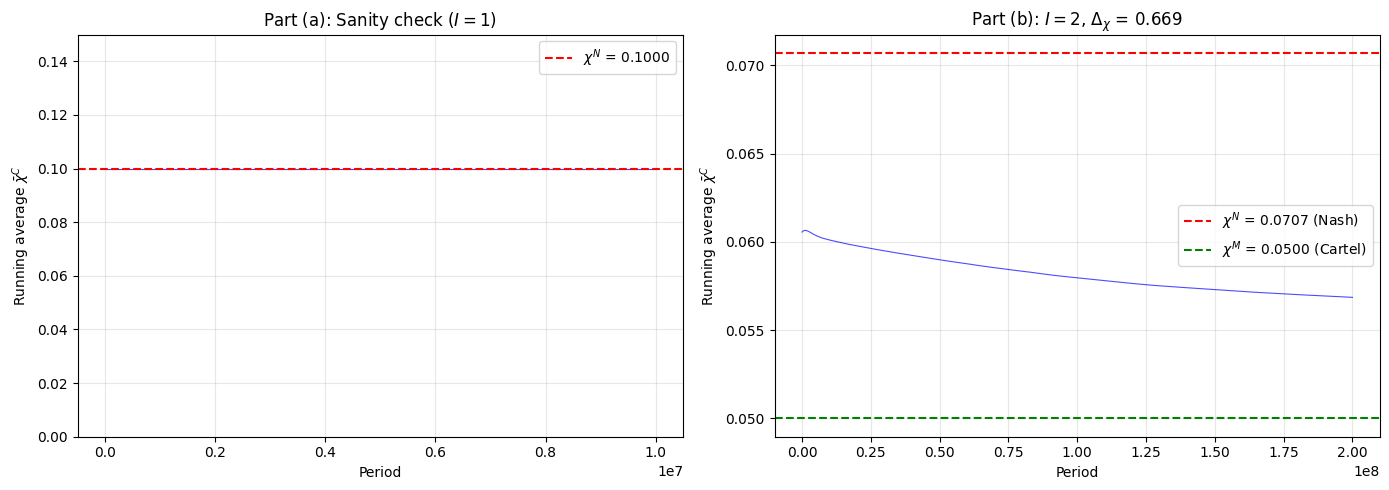

Convergence plot saved.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Part (a)
ax = axes[0]
x_ax_1 = np.linspace(0, T_1, len(chi_hist_1))
ax.plot(x_ax_1, chi_hist_1, 'b-', alpha=0.7, linewidth=0.8)
ax.axhline(y=chi_N_1, color='r', linestyle='--', label=f'$\chi^N$ = {chi_N_1:.4f}')
ax.set_xlabel('Period')
ax.set_ylabel(r'Running average $\bar{\chi}^C$')
ax.set_title(r'Part (a): Sanity check ($I=1$)')
ax.legend()
ax.grid(True, alpha=0.3)
# Set y-axis to a sensible range so matplotlib doesn't zoom into floating-point noise
ax.set_ylim([0, 0.15])

# Part (b)
ax = axes[1]
x_ax_2 = np.linspace(0, T_2, len(chi_hist_2))
ax.plot(x_ax_2, chi_hist_2, 'b-', alpha=0.7, linewidth=0.8)
ax.axhline(y=chi_N_2, color='r', linestyle='--', label=f'$\chi^N$ = {chi_N_2:.4f} (Nash)')
ax.axhline(y=chi_M_2, color='g', linestyle='--', label=f'$\chi^M$ = {chi_M_2:.4f} (Cartel)')
ax.set_xlabel('Period')
ax.set_ylabel(r'Running average $\bar{\chi}^C$')
ax.set_title(f'Part (b): $I=2$, $\Delta_\chi$ = {Delta_2:.3f}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('problem3_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Convergence plot saved.")


## 8. Summary

| | $\chi^N$ (Nash) | $\chi^M$ (Cartel) | $\bar{\chi}^C$ (Learned) | $\Delta_\chi$ |
|---|---|---|---|---|
| Part (a): $I=1$ | — | — | — | — |
| Part (b): $I=2$ | — | — | — | — |

*(Fill in from the output above.)*

**Interpretation:**
- If $\Delta_\chi \approx 0$: the algorithms learned to play Nash — no collusion.
- If $\Delta_\chi \in (0,1)$: partial collusion — the algorithms learned to trade more conservatively than Nash, extracting supra-competitive profits.
- If $\Delta_\chi \approx 1$: full collusion — behaviour equivalent to a perfect cartel.


---

# Problem 3(2): Information-Insensitive Investors ($\xi = 500$)

When $\xi = 500$, the equilibrium cannot be solved in closed form. We use the numerical solver from Problem 2(2) to compute $\chi^N$, $\chi^M$, and $\lambda^N$, then rebuild all discretisation grids with these new values and re-run the Q-learning simulation.

**Key differences from $\xi = 0$:**
- Equilibrium values are computed numerically via Brent's method
- $\lambda^N \approx 0.002$ (much smaller than 4.71 under $\xi = 0$), so price barely moves
- $\chi^N$ and $\chi^M$ are much larger (order $\sim 100$), since low $\lambda$ allows aggressive trading
- Training requires $T = 500 \times 10^6$ periods (10x longer) for convergence


## 9. Numerical Equilibrium Solver ($\xi > 0$)

Since the three-equation system $\chi$, $\lambda$, $\gamma$ cannot be solved in closed form when $\xi > 0$, we use Brent's method to find the fixed point of the mapping $\chi \to \hat{\chi}(\chi)$.


In [14]:
from scipy.optimize import brentq

def solve_equilibrium(I, sigma_v, sigma_u, theta, xi, mode='nash'):
    """
    Numerical solver for Nash or Cartel equilibrium when xi > 0.
    Uses Brent's method on the residual chi_new(chi) - chi = 0.
    """
    def residual(chi):
        gamma = I * chi / ((I * chi)**2 + (sigma_u / sigma_v)**2)
        lam = (theta * gamma + xi) / (theta + xi**2)
        if mode == 'nash':
            chi_new = 1.0 / ((I + 1) * lam)
        else:  # cartel
            chi_new = 1.0 / (2 * I * lam)
        return chi_new - chi

    chi_lo, chi_hi = 1e-12, 100.0
    for _ in range(10):
        if residual(chi_lo) * residual(chi_hi) < 0:
            break
        chi_hi *= 10

    chi_star = brentq(residual, chi_lo, chi_hi, xtol=1e-14)
    gamma_star = I * chi_star / ((I * chi_star)**2 + (sigma_u / sigma_v)**2)
    lam_star = (theta * gamma_star + xi) / (theta + xi**2)
    pi_star = (1 - lam_star * I * chi_star) * chi_star * sigma_v**2
    return chi_star, lam_star, gamma_star, pi_star

# Compute equilibrium for xi = 500
xi_val = 500
theta_val = 0.1
I_val = 2

chi_N_500, lam_N_500, gam_N_500, pi_N_500 = solve_equilibrium(
    I_val, sigma_v, sigma_u, theta_val, xi_val, 'nash')
chi_M_500, lam_M_500, gam_M_500, pi_M_500 = solve_equilibrium(
    I_val, sigma_v, sigma_u, theta_val, xi_val, 'cartel')

print(f"Equilibrium values (I=2, xi=500, theta=0.1):")
print(f"  Nash:   chi_N = {chi_N_500:.6f},  lambda_N = {lam_N_500:.8f},  pi_N = {pi_N_500:.4f}")
print(f"  Cartel: chi_M = {chi_M_500:.6f},  lambda_M = {lam_M_500:.8f},  pi_M = {pi_M_500:.4f}")
print(f"\nNote: chi values are ~100x larger than xi=0 case,")
print(f"       lambda is ~2000x smaller.")


Equilibrium values (I=2, xi=500, theta=0.1):
  Nash:   chi_N = 166.666633,  lambda_N = 0.00200000,  pi_N = 55.5555
  Cartel: chi_M = 124.999950,  lambda_M = 0.00200000,  pi_M = 62.5000

Note: chi values are ~100x larger than xi=0 case,
       lambda is ~2000x smaller.


## 10. Rebuild Discretisation Grids

The grids depend on $\chi^N$, $\chi^M$, and $\lambda^N$, which are completely different under $\xi = 500$. We rebuild everything from scratch using the numerically computed equilibrium values.


In [16]:
# Rebuild grids with xi=500 equilibrium values
v_grid_500 = build_v_grid(v_bar, sigma_v, n_v)
action_grids_500 = build_action_grids(v_grid_500, v_bar, chi_N_500, chi_M_500, n_x, iota)
price_grids_500 = build_price_grids(v_grid_500, v_bar, chi_N_500, chi_M_500, lam_N_500,
                                     I_val, sigma_u, n_p, iota)

# Show example grid for a positive v_k
k = 8
print(f"v_{k+1} = {v_grid_500[k]:.4f} (v_k - v_bar = {v_grid_500[k]-v_bar:+.4f})")
print(f"\nAction grid:")
print(f"  x_N_k = {chi_N_500*(v_grid_500[k]-v_bar):.4f}")
print(f"  x_M_k = {chi_M_500*(v_grid_500[k]-v_bar):.4f}")
print(f"  Range: [{action_grids_500[k][0]:.4f}, ..., {action_grids_500[k][-1]:.4f}]")
print(f"\nPrice grid:")
print(f"  Range: [{price_grids_500[k][0]:.6f}, ..., {price_grids_500[k][-1]:.6f}]")


v_9 = 2.0364 (v_k - v_bar = +1.0364)

Action grid:
  x_N_k = 172.7389
  x_M_k = 129.5541
  Range: [125.2356, ..., 177.0573]

Price grid:
  Range: [1.500472, ..., 1.708700]


## 11. Part (a): Q-Learning Simulation ($\xi = 500$, $I = 2$)

We run the Q-learning simulation for $T = 500 \times 10^6$ periods as specified. This is 10x longer than the $\xi = 0$ case because convergence is slower in the inventory-dominated regime.

**Note:** This simulation will take significantly longer to run. The project remark suggests $T \geq 200 \times 10^6$ may suffice.


In [21]:
# Run Q-learning for xi=500
T_500 = 500_000_000

print(f"Running Q-learning for T = {T_500:,} periods (xi=500)...")
print(f"  chi_N = {chi_N_500:.6f}, chi_M = {chi_M_500:.6f}, lambda_N = {lam_N_500:.8f}")
print()

chi_C_500, chi_hist_500, Delta_500,Q = run_qlearning(
    I=I_val, v_bar=v_bar, sigma_v=sigma_v, sigma_u=sigma_u,
    chi_N=chi_N_500, chi_M=chi_M_500, lambda_N=lam_N_500,
    rho=rho, alpha=alpha, beta=beta, iota=iota,
    n_v=n_v, n_x=n_x, n_p=n_p, T=T_500,
    print_every=50_000_000, seed=456
)

print(f"\n{'='*55}")
print(f"RESULTS (xi=500, I=2)")
print(f"{'='*55}")
print(f"  chi_N (Nash):       {chi_N_500:.6f}")
print(f"  chi_M (Cartel):     {chi_M_500:.6f}")
print(f"  chi_C (Learned):    {chi_C_500:.6f}")
print(f"  Collusion index:    Delta = {Delta_500:.4f}")
print(f"    (0 = Nash, 1 = Perfect cartel)")


Running Q-learning for T = 500,000,000 periods (xi=500)...
  chi_N = 166.666633, chi_M = 124.999950, lambda_N = 0.00200000



KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

x_ax = np.linspace(0, T_500, len(chi_hist_500))
ax.plot(x_ax, chi_hist_500, 'b-', alpha=0.7, linewidth=0.8)
ax.axhline(y=chi_N_500, color='r', linestyle='--',
           label=f'$\chi^N$ = {chi_N_500:.4f} (Nash)')
ax.axhline(y=chi_M_500, color='g', linestyle='--',
           label=f'$\chi^M$ = {chi_M_500:.4f} (Cartel)')
ax.set_xlabel('Period')
ax.set_ylabel(r'Running average $\bar{\chi}^C$')
ax.set_title(rf'$\xi = 500$, $I=2$, $\Delta_\chi$ = {Delta_500:.3f}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('problem3_xi500_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Convergence plot saved.")


In [ ]:
print(f"{'='*60}")
print(f"Comparison of collusion indices")
print(f"{'='*60}")
print(f"{'Regime':<15} {'chi_N':>10} {'chi_M':>10} {'chi_C':>10} {'Delta':>8}")
print(f"{'-'*60}")
print(f"{'xi = 0':<15} {chi_N_2:>10.6f} {chi_M_2:>10.6f} {chi_C_2:>10.6f} {Delta_2:>8.4f}")
print(f"{'xi = 500':<15} {chi_N_500:>10.6f} {chi_M_500:>10.6f} {chi_C_500:>10.6f} {Delta_500:>8.4f}")
print()
print(f"Key finding:")
if Delta_500 > Delta_2:
    print(f"  Delta(xi=500) = {Delta_500:.4f} > Delta(xi=0) = {Delta_2:.4f}")
    print(f"  => More collusion with information-insensitive investors.")
else:
    print(f"  Delta(xi=500) = {Delta_500:.4f} <= Delta(xi=0) = {Delta_2:.4f}")
    print(f"  => Less or equal collusion with information-insensitive investors.")


Comparison of collusion indices
Regime               chi_N      chi_M      chi_C    Delta
------------------------------------------------------------
xi = 0            0.070711   0.050000   0.058995   0.5657
xi = 500        166.666633 124.999950 137.773620   0.6934

Key finding:
  Delta(xi=500) = 0.6934 > Delta(xi=0) = 0.5657
  => More collusion with information-insensitive investors.


In [ ]:
Delta_500

np.float64(0.6934320387879411)

In [ ]:
import pandas as pd

pd.DataFrame(chi_hist_500).to_csv('chi_hist_500.csv', index=False)


---

# Problem 3(3): Impulse Response Analysis

To distinguish between the two collusion mechanisms (price-trigger vs over-pruning bias), we run a **noise shock impulse response function (IRF)**.

**Idea:** At $t=3$, inject a noise shock into $u_3$ and observe how prices, order flows, and profits respond in subsequent periods.

- **Price-trigger signature:** At $t=4$, speculators detect the price anomaly and increase trading (punishment) → order flow deviation positive, price deviation amplified.
- **Over-pruning signature:** At $t=4$, speculators do not adjust → order flow deviation near zero, price deviation dampens naturally.

**Procedure:**
1. Freeze Q-matrix after training (no further updates)
2. Draw $N_{sim} = 1000$ paths of $(v_1, \ldots, v_9)$ and $(u_1, \ldots, u_9)$
3. Simulate each path twice: baseline (no shock) and shocked ($u_3 \leftarrow u_3 + u_{\text{shock}} \cdot \text{sgn}(v_3 - \bar{v})$)
4. Three shock sizes: 0.5%, 2.5%, 7% of $\mathbb{E}[|x_i|]$
5. Compute sign-adjusted variables and report percentage deviations


In [18]:
def compute_avg_abs_x(Q, v_grid, action_grids, price_grids, v_bar,
                      sigma_u, lambda_N, I, n_v, n_p, N=100_000, seed=999):
    # Estimate E[|x_i|] under the learned (greedy) policy
    np.random.seed(seed)
    abs_x_sum = 0.0
    vp = np.random.randint(n_v)
    vc = np.random.randint(n_v)
    pp = np.random.randint(n_p)
    for _ in range(N):
        X_k = action_grids[vc]
        ai = np.argmax(Q[pp, vp, vc, :len(X_k)])
        x_i = X_k[ai]
        abs_x_sum += abs(x_i)
        u_t = np.random.normal(0, sigma_u)
        p_t = v_bar + lambda_N * (I * x_i + u_t)
        pc = snap_to_grid(p_t, price_grids[vc])
        vn = np.random.randint(n_v)
        pp, vp, vc = pc, vc, vn
    return abs_x_sum / N


def simulate_path(Q, v_seq, u_seq, v_grid, action_grids, price_grids,
                  v_bar, lambda_N, I, n_v, n_p, shock_t=None, shock_val=0.0,
                  init_state=None):
    # Simulate one H-period path using frozen Q-matrix
    H = len(v_seq)
    p_prev_idx, v_prev_idx = init_state
    p_tildes = np.zeros(H)
    x_tildes = np.zeros(H)
    profits = np.zeros(H)

    for t in range(H):
        vc = v_seq[t]
        X_k = action_grids[vc]
        ai = np.argmax(Q[p_prev_idx, v_prev_idx, vc, :len(X_k)])
        x_i = X_k[ai]

        u_t = u_seq[t]
        if shock_t is not None and t == shock_t:
            u_t = u_t + shock_val * np.sign(v_grid[vc] - v_bar)

        y_t = I * x_i + u_t
        p_t = v_bar + lambda_N * y_t
        v_t = v_grid[vc]
        profit = (v_t - p_t) * x_i

        sgn_v = np.sign(v_t - v_bar) if abs(v_t - v_bar) > 1e-10 else 1.0
        p_tildes[t] = (p_t - v_bar) * sgn_v
        x_tildes[t] = x_i * sgn_v
        profits[t] = profit

        pc = snap_to_grid(p_t, price_grids[vc])
        p_prev_idx = pc
        v_prev_idx = vc

    return {'p_tilde': p_tildes, 'x_tilde': x_tildes, 'profit': profits}


def run_irf(Q, v_grid, action_grids, price_grids, v_bar, sigma_v, sigma_u,
            lambda_N, I, n_v, n_p, shock_fractions, N_sim=1000, H=9, seed=789):
    # Run full IRF analysis
    np.random.seed(seed)
    avg_abs_x = compute_avg_abs_x(Q, v_grid, action_grids, price_grids,
                                   v_bar, sigma_u, lambda_N, I, n_v, n_p)
    print(f"  E[|x_i|] = {avg_abs_x:.6f}")
    shock_sizes = [f * avg_abs_x for f in shock_fractions]
    print(f"  Shock sizes: {[f'{s:.6f}' for s in shock_sizes]}")

    v_seqs = np.random.randint(0, n_v, size=(N_sim, H))
    u_seqs = np.random.normal(0, sigma_u, size=(N_sim, H))
    init_vp = np.random.randint(0, n_v, size=N_sim)
    init_pp = np.random.randint(0, n_p, size=N_sim)

    results = {}
    for frac, shock_val in zip(shock_fractions, shock_sizes):
        label = f"{frac*100:.1f}%"
        print(f"  Running IRF for shock = {label} of E[|x_i|]...")
        base_p = np.zeros(H); base_x = np.zeros(H); base_pi = np.zeros(H)
        shk_p = np.zeros(H);  shk_x = np.zeros(H);  shk_pi = np.zeros(H)

        for n in range(N_sim):
            init = (init_pp[n], init_vp[n])
            rb = simulate_path(Q, v_seqs[n], u_seqs[n], v_grid, action_grids,
                               price_grids, v_bar, lambda_N, I, n_v, n_p,
                               shock_t=None, shock_val=0.0, init_state=init)
            rs = simulate_path(Q, v_seqs[n], u_seqs[n], v_grid, action_grids,
                               price_grids, v_bar, lambda_N, I, n_v, n_p,
                               shock_t=2, shock_val=shock_val, init_state=init)
            base_p += rb['p_tilde']; base_x += rb['x_tilde']; base_pi += rb['profit']
            shk_p += rs['p_tilde'];  shk_x += rs['x_tilde'];  shk_pi += rs['profit']

        base_p /= N_sim; base_x /= N_sim; base_pi /= N_sim
        shk_p /= N_sim;  shk_x /= N_sim;  shk_pi /= N_sim

        def pct_dev(s, b):
            return np.array([(s[t]-b[t])/abs(b[t]) if abs(b[t])>1e-15 else 0.0 for t in range(H)])

        results[label] = {
            'price_dev': pct_dev(shk_p, base_p),
            'order_dev': pct_dev(shk_x, base_x),
            'profit_dev': pct_dev(shk_pi, base_pi),
        }
    return results


def plot_irf(results, title_suffix=""):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    periods = np.arange(1, 10)
    colors = ['b', 'r', 'g']
    styles = ['-o', '--s', '-.^']
    for ax, key, ylabel in zip(axes,
            ['price_dev', 'profit_dev', 'order_dev'],
            ['Price deviation', 'Profit deviation', 'Order flow deviation']):
        for i, (label, res) in enumerate(results.items()):
            ax.plot(periods, res[key], styles[i], color=colors[i],
                    label=label, markersize=5, linewidth=1.5)
        ax.axvline(x=3, color='gray', linestyle=':', alpha=0.5, label='shock')
        ax.axhline(y=0, color='k', linestyle='-', alpha=0.2)
        ax.set_xlabel('Period'); ax.set_ylabel(ylabel)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    fig.suptitle(f'Impulse Response Function {title_suffix}', fontsize=13)
    plt.tight_layout()
    return fig

## 16. IRF for $\xi = 0$

We use a freshly trained Q-matrix for $\xi = 0$, $I = 2$.

In [25]:
# Train Q-matrix for xi=0 (returning Q and grids)
def run_qlearning_full(I, v_bar, sigma_v, sigma_u, chi_N, chi_M, lambda_N,
                       rho, alpha, beta, iota, n_v, n_x, n_p, T,
                       print_every=50_000_000, seed=42):
    # Same as run_qlearning but returns Q, grids
    np.random.seed(seed)
    v_grid = build_v_grid(v_bar, sigma_v, n_v)
    action_grids = build_action_grids(v_grid, v_bar, chi_N, chi_M, n_x, iota)
    price_grids = build_price_grids(v_grid, v_bar, chi_N, chi_M, lambda_N,
                                    I, sigma_u, n_p, iota)
    Q = init_Q_matrix(v_grid, action_grids, price_grids, v_bar, lambda_N,
                      I, rho, n_v, n_p)
    vp = np.random.randint(n_v); vc = np.random.randint(n_v)
    pp = np.random.randint(n_p)
    visits = np.zeros(n_v, dtype=np.int64)
    asum, acnt = 0.0, 0
    start = time.time()
    for t in range(1, T+1):
        visits[vc] += 1
        eps = np.exp(-beta * visits[vc])
        Xk = action_grids[vc]; nxk = len(Xk)
        if np.random.random() < eps: ai = np.random.randint(nxk)
        else: ai = np.argmax(Q[pp, vp, vc, :nxk])
        xi = Xk[ai]
        ut = np.random.normal(0, sigma_u)
        pt = v_bar + lambda_N * (I*xi + ut)
        vt = v_grid[vc]; profit = (vt - pt) * xi
        vn = np.random.randint(n_v)
        pc = snap_to_grid(pt, price_grids[vc])
        mxQ = np.max(Q[pc, vc, vn, :len(action_grids[vn])])
        Q[pp, vp, vc, ai] = (1-alpha)*Q[pp, vp, vc, ai] + alpha*(profit + rho*mxQ)
        if abs(vt - v_bar) > 1e-10: asum += xi/(vt-v_bar); acnt += 1
        pp, vp, vc = pc, vc, vn
        if t % print_every == 0:
            print(f"  t={t:>12,d} | chi_C={asum/acnt:.6f} | {time.time()-start:.0f}s")
    chi_C = asum/acnt if acnt > 0 else 0
    Delta = (chi_N - chi_C)/(chi_N - chi_M) if abs(chi_N-chi_M)>1e-15 else 0
    return Q, v_grid, action_grids, price_grids, chi_C, Delta

print("Training Q-matrix for xi=0, I=2, T=200M...")
def run_qlearning_v2(I, v_bar, sigma_v, sigma_u, chi_N, chi_M, lambda_N,
                  rho, alpha, beta, iota, n_v, n_x, n_p, T,
                  print_every=2_000_000, seed=42):
    """
    Run the full Q-learning simulation.

    Returns:
      chi_C:        average learned trading intensity after convergence
      chi_history:  list of running-average chi values (for convergence plot)
      Delta:        collusion index
    """
    np.random.seed(seed)

    # ---- Build grids ----
    v_grid = build_v_grid(v_bar, sigma_v, n_v)
    action_grids = build_action_grids(v_grid, v_bar, chi_N, chi_M, n_x, iota)
    price_grids = build_price_grids(v_grid, v_bar, chi_N, chi_M, lambda_N, I, sigma_u, n_p, iota)

    # ---- Initialise Q-matrix ----
    Q = init_Q_matrix(v_grid, action_grids, price_grids, v_bar, lambda_N, I, rho, n_v, n_p)

    # ---- Initialise state ----
    v_prev_idx = np.random.randint(n_v)
    v_curr_idx = np.random.randint(n_v)
    p_prev_idx = np.random.randint(n_p)

    # ---- Visit counters for epsilon decay ----
    visit_counts = np.zeros(n_v, dtype=np.int64)

    # ---- Tracking ----
    chi_history = []
    record_every = max(T // 500, 1)
    action_sum = 0.0
    action_count = 0

    start_time = time.time()

    for t in range(1, T + 1):
        # Step 1: state is (p_prev_idx, v_prev_idx, v_curr_idx)

        # Step 2: epsilon-greedy action selection
        visit_counts[v_curr_idx] += 1
        epsilon = np.exp(-beta * visit_counts[v_curr_idx])

        X_k = action_grids[v_curr_idx]
        n_x_k = len(X_k)

        if np.random.random() < epsilon:
            action_idx = np.random.randint(n_x_k)   # explore
        else:
            q_vals = Q[p_prev_idx, v_prev_idx, v_curr_idx, :n_x_k]
            action_idx = np.argmax(q_vals)            # exploit

        x_i = X_k[action_idx]

        # Step 3: market clears
        u_t = np.random.normal(0, sigma_u)
        y_t = I * x_i + u_t
        p_t = v_bar + lambda_N * y_t
        v_t = v_grid[v_curr_idx]
        profit = (v_t - p_t) * x_i

        # Step 4: transition
        v_next_idx = np.random.randint(n_v)
        p_curr_idx = snap_to_grid(p_t, price_grids[v_curr_idx])

        # Step 5: update Q-matrix
        X_next = action_grids[v_next_idx]
        max_Q_next = np.max(Q[p_curr_idx, v_curr_idx, v_next_idx, :len(X_next)])
        td_target = profit + rho * max_Q_next

        Q[p_prev_idx, v_prev_idx, v_curr_idx, action_idx] = (
            (1 - alpha) * Q[p_prev_idx, v_prev_idx, v_curr_idx, action_idx]
            + alpha * td_target
        )

        # Track chi
        if abs(v_t - v_bar) > 1e-10:
            action_sum += x_i / (v_t - v_bar)
            action_count += 1

        if t % record_every == 0 and action_count > 0:
            chi_history.append(action_sum / action_count)

        # Advance state
        p_prev_idx = p_curr_idx
        v_prev_idx = v_curr_idx
        v_curr_idx = v_next_idx

        # Progress
        if t % print_every == 0:
            elapsed = time.time() - start_time
            avg_chi = action_sum / action_count if action_count > 0 else 0
            avg_eps = np.mean([np.exp(-beta * vc) for vc in visit_counts])
            print(f"  t={t:>12,d} | chi_C={avg_chi:.6f} | "
                  f"avg_eps={avg_eps:.4f} | {elapsed:.0f}s")

    chi_C = action_sum / action_count if action_count > 0 else 0
    Delta = (chi_N - chi_C) / (chi_N - chi_M) if abs(chi_N - chi_M) > 1e-15 else 0.0

    return chi_C, chi_history, Delta, Q, v_grid, action_grids, price_grids
chi_N_2, chi_M_2, lam_N_2, _, _, _ = compute_equilibrium_xi0(2, sigma_v, sigma_u)


cC0, hist0, D0, Q_xi0, vg0, ag0, pg0 = run_qlearning_v2(
    2, v_bar, sigma_v, sigma_u, chi_N_2, chi_M_2, lam_N_2,
    rho, alpha, beta, iota, n_v, n_x, n_p, 50_000_000, seed=123)
print(f"Done. chi_C={cC0:.6f}, Delta={D0:.4f}")

Training Q-matrix for xi=0, I=2, T=200M...
  t=   2,000,000 | chi_C=0.060641 | avg_eps=0.3679 | 13s
  t=   4,000,000 | chi_C=0.060486 | avg_eps=0.1353 | 25s
  t=   6,000,000 | chi_C=0.060323 | avg_eps=0.0498 | 38s
  t=   8,000,000 | chi_C=0.060208 | avg_eps=0.0183 | 50s
  t=  10,000,000 | chi_C=0.060123 | avg_eps=0.0067 | 63s
  t=  12,000,000 | chi_C=0.060043 | avg_eps=0.0025 | 75s
  t=  14,000,000 | chi_C=0.059973 | avg_eps=0.0009 | 87s
  t=  16,000,000 | chi_C=0.059907 | avg_eps=0.0003 | 100s
  t=  18,000,000 | chi_C=0.059841 | avg_eps=0.0001 | 113s
  t=  20,000,000 | chi_C=0.059784 | avg_eps=0.0000 | 126s
  t=  22,000,000 | chi_C=0.059724 | avg_eps=0.0000 | 138s
  t=  24,000,000 | chi_C=0.059667 | avg_eps=0.0000 | 151s
  t=  26,000,000 | chi_C=0.059608 | avg_eps=0.0000 | 163s
  t=  28,000,000 | chi_C=0.059558 | avg_eps=0.0000 | 176s
  t=  30,000,000 | chi_C=0.059502 | avg_eps=0.0000 | 189s
  t=  32,000,000 | chi_C=0.059451 | avg_eps=0.0000 | 202s
  t=  34,000,000 | chi_C=0.059394 | 

Running IRF for xi=0...
  E[|x_i|] = 0.043757
  Shock sizes: ['0.000219', '0.001094', '0.003063']
  Running IRF for shock = 0.5% of E[|x_i|]...
  Running IRF for shock = 2.5% of E[|x_i|]...
  Running IRF for shock = 7.0% of E[|x_i|]...


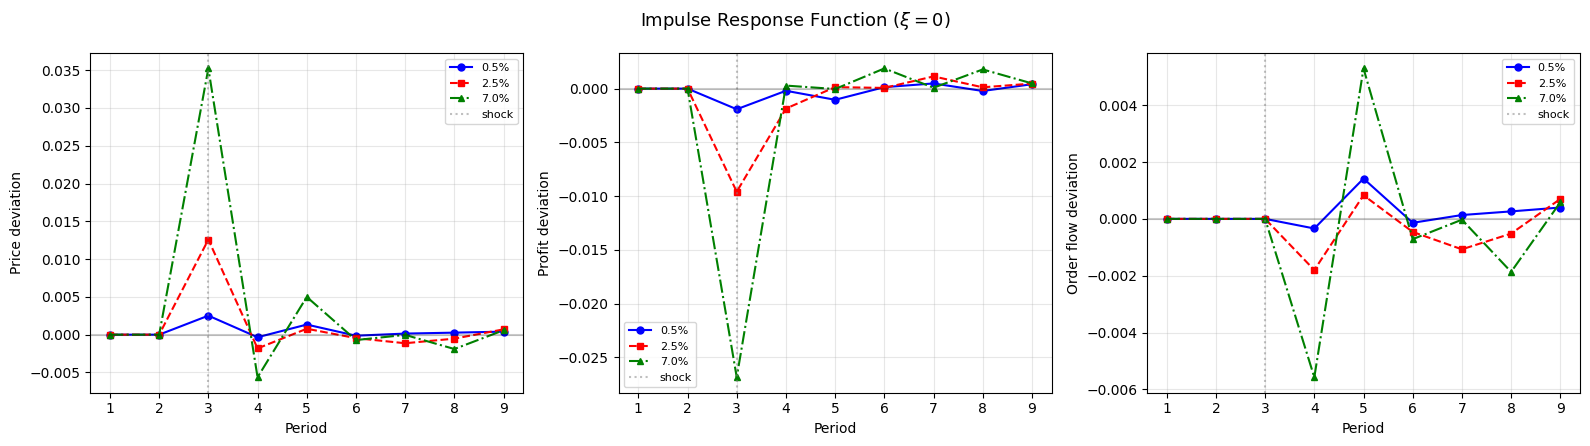

In [26]:
# Run IRF for xi=0
print("Running IRF for xi=0...")
irf_xi0 = run_irf(Q_xi0, vg0, ag0, pg0, v_bar, sigma_v, sigma_u,
                   lam_N_2, I=2, n_v=n_v, n_p=n_p,
                   shock_fractions=[0.005, 0.025, 0.07], N_sim=1000, seed=789)
fig0 = plot_irf(irf_xi0, title_suffix=r"($\xi = 0$)")
plt.savefig('irf_xi0.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. IRF for $\xi = 500$

In [19]:
def run_qlearning_v2(I, v_bar, sigma_v, sigma_u, chi_N, chi_M, lambda_N,
                  rho, alpha, beta, iota, n_v, n_x, n_p, T,
                  print_every=2_000_000, seed=42):
    """
    Run the full Q-learning simulation.

    Returns:
      chi_C:        average learned trading intensity after convergence
      chi_history:  list of running-average chi values (for convergence plot)
      Delta:        collusion index
    """
    np.random.seed(seed)

    # ---- Build grids ----
    v_grid = build_v_grid(v_bar, sigma_v, n_v)
    action_grids = build_action_grids(v_grid, v_bar, chi_N, chi_M, n_x, iota)
    price_grids = build_price_grids(v_grid, v_bar, chi_N, chi_M, lambda_N, I, sigma_u, n_p, iota)

    # ---- Initialise Q-matrix ----
    Q = init_Q_matrix(v_grid, action_grids, price_grids, v_bar, lambda_N, I, rho, n_v, n_p)

    # ---- Initialise state ----
    v_prev_idx = np.random.randint(n_v)
    v_curr_idx = np.random.randint(n_v)
    p_prev_idx = np.random.randint(n_p)

    # ---- Visit counters for epsilon decay ----
    visit_counts = np.zeros(n_v, dtype=np.int64)

    # ---- Tracking ----
    chi_history = []
    record_every = max(T // 500, 1)
    action_sum = 0.0
    action_count = 0

    start_time = time.time()

    for t in range(1, T + 1):
        # Step 1: state is (p_prev_idx, v_prev_idx, v_curr_idx)

        # Step 2: epsilon-greedy action selection
        visit_counts[v_curr_idx] += 1
        epsilon = np.exp(-beta * visit_counts[v_curr_idx])

        X_k = action_grids[v_curr_idx]
        n_x_k = len(X_k)

        if np.random.random() < epsilon:
            action_idx = np.random.randint(n_x_k)   # explore
        else:
            q_vals = Q[p_prev_idx, v_prev_idx, v_curr_idx, :n_x_k]
            action_idx = np.argmax(q_vals)            # exploit

        x_i = X_k[action_idx]

        # Step 3: market clears
        u_t = np.random.normal(0, sigma_u)
        y_t = I * x_i + u_t
        p_t = v_bar + lambda_N * y_t
        v_t = v_grid[v_curr_idx]
        profit = (v_t - p_t) * x_i

        # Step 4: transition
        v_next_idx = np.random.randint(n_v)
        p_curr_idx = snap_to_grid(p_t, price_grids[v_curr_idx])

        # Step 5: update Q-matrix
        X_next = action_grids[v_next_idx]
        max_Q_next = np.max(Q[p_curr_idx, v_curr_idx, v_next_idx, :len(X_next)])
        td_target = profit + rho * max_Q_next

        Q[p_prev_idx, v_prev_idx, v_curr_idx, action_idx] = (
            (1 - alpha) * Q[p_prev_idx, v_prev_idx, v_curr_idx, action_idx]
            + alpha * td_target
        )

        # Track chi
        if abs(v_t - v_bar) > 1e-10:
            action_sum += x_i / (v_t - v_bar)
            action_count += 1

        if t % record_every == 0 and action_count > 0:
            chi_history.append(action_sum / action_count)

        # Advance state
        p_prev_idx = p_curr_idx
        v_prev_idx = v_curr_idx
        v_curr_idx = v_next_idx

        # Progress
        if t % print_every == 0:
            elapsed = time.time() - start_time
            avg_chi = action_sum / action_count if action_count > 0 else 0
            avg_eps = np.mean([np.exp(-beta * vc) for vc in visit_counts])
            print(f"  t={t:>12,d} | chi_C={avg_chi:.6f} | "
                  f"avg_eps={avg_eps:.4f} | {elapsed:.0f}s")

    chi_C = action_sum / action_count if action_count > 0 else 0
    Delta = (chi_N - chi_C) / (chi_N - chi_M) if abs(chi_N - chi_M) > 1e-15 else 0.0

    return chi_C, chi_history, Delta, Q, v_grid, action_grids, price_grids

In [20]:
from scipy.optimize import brentq

def solve_eq(I, sv, su, th, xi, mode):
    def res(chi):
        g = I*chi/((I*chi)**2+(su/sv)**2)
        l = (th*g+xi)/(th+xi**2)
        return (1/((I+1)*l) if mode=='nash' else 1/(2*I*l)) - chi
    lo, hi = 1e-12, 100.0
    for _ in range(10):
        if res(lo)*res(hi)<0: break
        hi *= 10
    c = brentq(res, lo, hi, xtol=1e-14)
    g = I*c/((I*c)**2+(su/sv)**2)
    return c, (th*g+xi)/(th+xi**2)

print("Training Q-matrix for xi=500, I=2, T=500M...")
cN5, lN5 = solve_eq(2, sigma_v, sigma_u, 0.1, 500, 'nash')
cM5, lM5 = solve_eq(2, sigma_v, sigma_u, 0.1, 500, 'cartel')
cC5, hist5, D5, Q_xi5, vg5, ag5, pg5  = run_qlearning_v2(
    2, v_bar, sigma_v, sigma_u, cN5, cM5, lN5,
    rho, alpha, beta, iota, n_v, n_x, n_p, 500_000_000,
    print_every=100_000_000, seed=456)
print(f"Done. chi_C={cC5:.6f}, Delta={D5:.4f}")

Training Q-matrix for xi=500, I=2, T=500M...
  t= 100,000,000 | chi_C=140.938632 | avg_eps=0.0000 | 656s
  t= 200,000,000 | chi_C=139.371081 | avg_eps=0.0000 | 1313s
  t= 300,000,000 | chi_C=138.738570 | avg_eps=0.0000 | 1965s
  t= 400,000,000 | chi_C=138.233874 | avg_eps=0.0000 | 2647s
  t= 500,000,000 | chi_C=137.773620 | avg_eps=0.0000 | 3295s
Done. chi_C=137.773620, Delta=0.6934


Running IRF for xi=500...
  E[|x_i|] = 102.390182
  Shock sizes: ['0.511951', '2.559755', '7.167313']
  Running IRF for shock = 0.5% of E[|x_i|]...
  Running IRF for shock = 2.5% of E[|x_i|]...
  Running IRF for shock = 7.0% of E[|x_i|]...


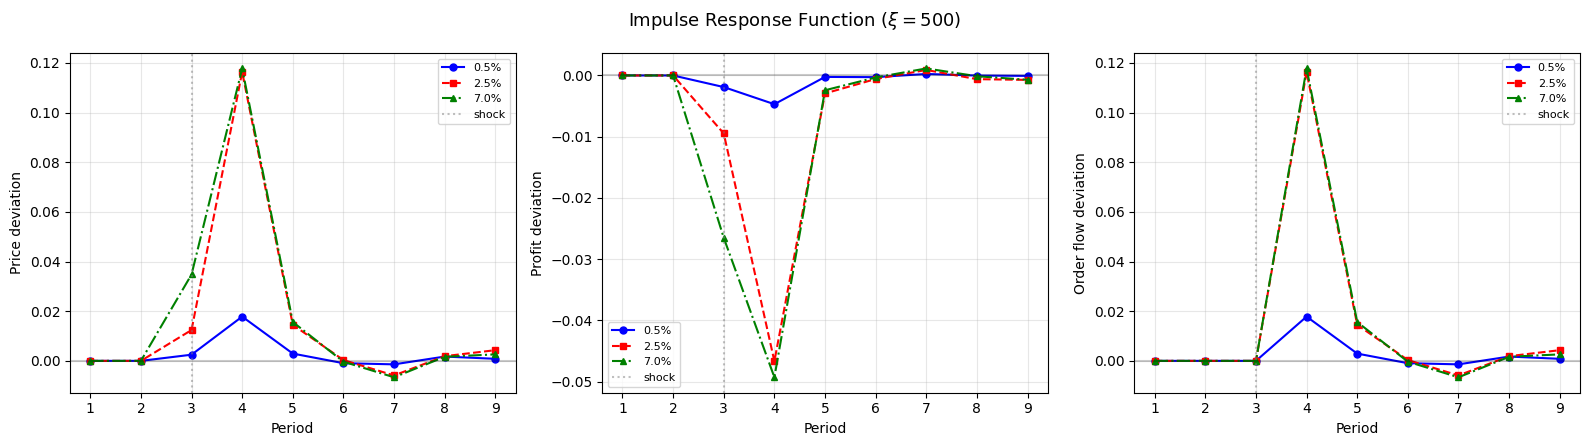

In [21]:
# Run IRF for xi=500
print("Running IRF for xi=500...")
irf_xi500 = run_irf(Q_xi5, vg5, ag5, pg5, v_bar, sigma_v, sigma_u,
                     lN5, I=2, n_v=n_v, n_p=n_p,
                     shock_fractions=[0.005, 0.025, 0.07], N_sim=1000, seed=789)
fig5 = plot_irf(irf_xi500, title_suffix=r"($\xi = 500$)")
plt.savefig('irf_xi500.png', dpi=150, bbox_inches='tight')
plt.show()

## 18. IRF Comparison and Interpretation

**Key diagnostics at $t = 4$:**
- Order flow deviation > 0 → punishment → price-trigger
- Order flow deviation ≈ 0 → no punishment → over-pruning

**Price deviation at $t = 4$:**
- Amplified → price-trigger
- Dampened → over-pruning



In [27]:
# Print key IRF values
print("=" * 70)
print("IRF values at t=3 (shock) and t=4 (response)")
print("=" * 70)
for regime, irf_res in [("xi=0", irf_xi0), ("xi=500", irf_xi500)]:
    print(f"\n--- {regime} ---")
    print(f"{'Shock':>8} | {'Price t=3':>10} {'Price t=4':>10} | "
          f"{'Order t=3':>10} {'Order t=4':>10} | "
          f"{'Profit t=3':>11} {'Profit t=4':>11}")
    print("-" * 70)
    for label, res in irf_res.items():
        p3, p4 = res['price_dev'][2], res['price_dev'][3]
        x3, x4 = res['order_dev'][2], res['order_dev'][3]
        pi3, pi4 = res['profit_dev'][2], res['profit_dev'][3]
        print(f"{label:>8} | {p3:>10.4f} {p4:>10.4f} | "
              f"{x3:>10.4f} {x4:>10.4f} | {pi3:>11.4f} {pi4:>11.4f}")
print("\nInterpretation:")
print("  order_dev t=4 > 0 => price-trigger")
print("  order_dev t=4 ~ 0 => over-pruning")
print("  price_dev t=4 > t=3 => amplification (price-trigger)")
print("  price_dev t=4 < t=3 => dampening (over-pruning)")

IRF values at t=3 (shock) and t=4 (response)

--- xi=0 ---
   Shock |  Price t=3  Price t=4 |  Order t=3  Order t=4 |  Profit t=3  Profit t=4
----------------------------------------------------------------------
    0.5% |     0.0025    -0.0003 |     0.0000    -0.0003 |     -0.0019     -0.0002
    2.5% |     0.0126    -0.0018 |     0.0000    -0.0018 |     -0.0096     -0.0019
    7.0% |     0.0352    -0.0056 |     0.0000    -0.0056 |     -0.0268      0.0003

--- xi=500 ---
   Shock |  Price t=3  Price t=4 |  Order t=3  Order t=4 |  Profit t=3  Profit t=4
----------------------------------------------------------------------
    0.5% |     0.0025     0.0178 |     0.0000     0.0178 |     -0.0019     -0.0047
    2.5% |     0.0124     0.1164 |     0.0000     0.1164 |     -0.0095     -0.0467
    7.0% |     0.0348     0.1178 |     0.0000     0.1178 |     -0.0265     -0.0493

Interpretation:
  order_dev t=4 > 0 => price-trigger
  order_dev t=4 ~ 0 => over-pruning
  price_dev t=4 > t=3 => ampl